<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# Lab: Comparing tSNE and UMAP Dimension Reduction Models
Estimated time needed: **30** minutes
    

## Objectives

After completing this lab you will be able to:

* Apply tSNE and UMAP to feature space dimensionality reduction problems
* Use PCA as a baseline comparison for evaluating tSNE and UMAP results



## Introduction

In this lab, you will explore how to implement two advanced dimensionality reduction algorithms, tSNE and UMAP, on synthetic data.
You'll compare the results to the same dimension reduction using PCA.

- You'll start by generating a synthetic dataset of blobs in a 3D feature space and visually explore the data in an interactive 3D plot. 
- Then, you'll use the three algorithms to project the blobs into two dimensions.
  
For illustrative purposes, you'll color the blobs so we can see what effect the dimension reduction algorithms have on them: how well they preserve structure, such as the separation between blobs and their relative density.


### Import the required libraries


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

import umap.umap_ as UMAP 
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import plotly.express as px
from sklearn.datasets import make_blobs

### Generate synthetic data with four clusters in a 3D space


In [5]:
# CLuster centers:
centers = [ [ 2, -6, -6],
            [-1,  9,  4],
            [-8,  7,  2],
            [ 4,  7,  9] ]

# Cluster standard deviations:
cluster_std=[1,1,2,3.5]

# Make the blobs and return the data and the blob labels
X, labels_ = make_blobs(n_samples=500, centers=centers, n_features=3, cluster_std=cluster_std, random_state=42)

### Display the data in an interactive Plotly 3D scatter plot


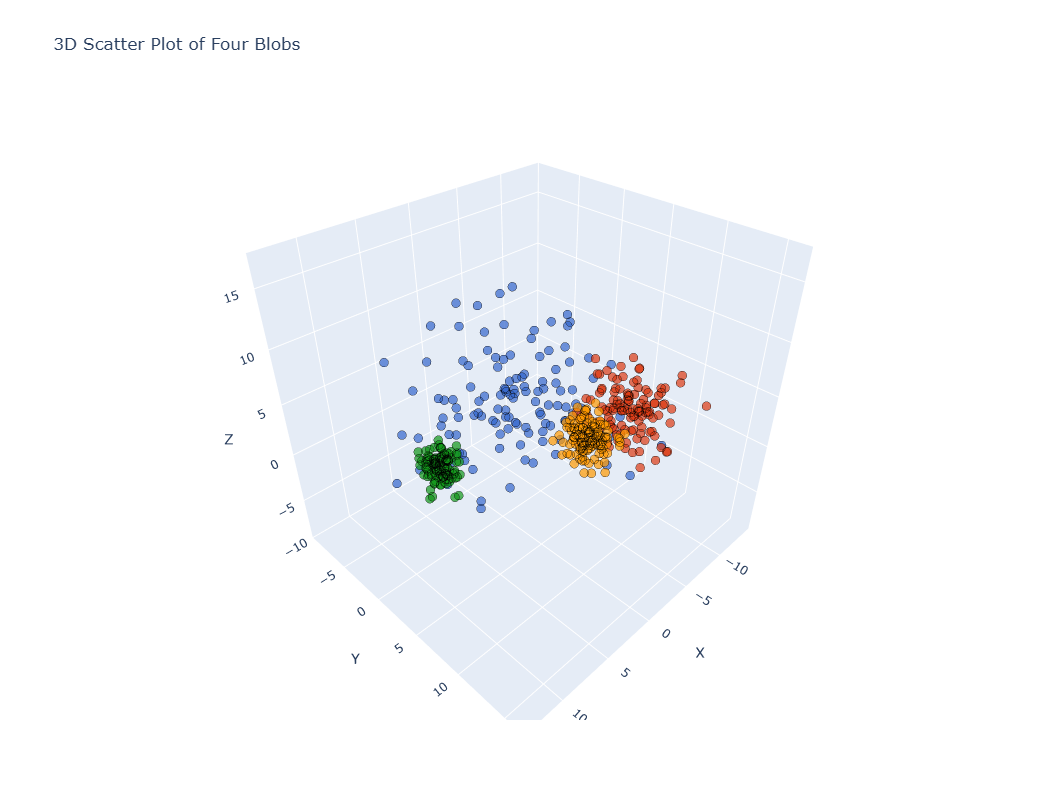

In [6]:
# Create a DataFrame for Plotly
df = pd.DataFrame(X, columns=['X', 'Y', 'Z'])

# Create interactive 3D scatter plot
fig = px.scatter_3d(df, x='X', y='Y', z='Z', color=labels_.astype(str) ,  opacity=0.7,  color_discrete_sequence=px.colors.qualitative.G10, title="3D Scatter Plot of Four Blobs")

fig.update_traces(marker=dict(size=5, line=dict(width=1, color='black')), showlegend=False)
fig.update_layout(coloraxis_showscale=False, width=1000, height=800)  # Remove color bar, resize plot

fig.show()

### Interact with the plot
Go ahead and click on the icons at the top right of the plot to select zoom, rotate, and pan modes.

Then use your mouse to interact with the plot. 

This is a great way to inspect 3D data as it's difficult to learn much from a static 3D plot.
### Exercise 1. What can you say about the four blobs?


We can see that all blobs have different densities. The green blob is completely separate from the other blobs. The blue and red blobs are the largest, but they are distinct from eachother, though both overlap with the orange blob.

### Exercise 2. Standardize the data to prepare it for the three projection methods.


In [8]:
# Enter your code here:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Apply t-SNE to reduce the dimensionality to 2D
You'll set the perplexity to the default value of 30 here. The results vary quite a bit if you change the perplexity, so go ahead and experiment.


In [9]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

### Let's plot the 2D t-SNE result


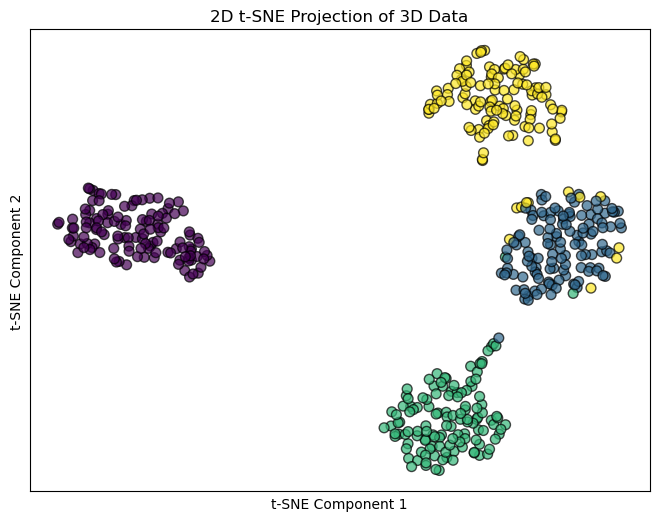

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax.set_title("2D t-SNE Projection of 3D Data")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_xticks([])
ax.set_yticks([])
plt.show()

### Exercise 3. What can you say about this t-SNE result?


t-SNE manages to separate the blobs very well, but we can see in the blue blob that we have some incorrect points as some of the overlapping points ended up in the wrong cluster. The densities of the blobs are very similar. The distance between the blobs is consistent with how it was in the original plot

## Compare UMAP and PCA dimensionality reduction to two dimensions


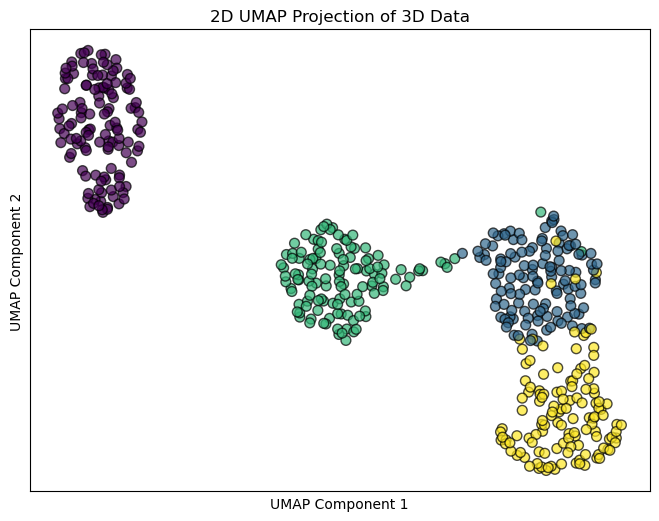

In [12]:
# Apply UMAP to reduce the dimensionality to 2D
umap_model = UMAP.UMAP(n_components=2, random_state=42, min_dist=0.5, spread=1,n_jobs=1)

X_umap = umap_model.fit_transform(X_scaled)

# Plot the 2D UMAP projection result 
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')

ax.set_title("2D UMAP Projection of 3D Data")
ax.set_xlabel("UMAP Component 1", )
ax.set_ylabel("UMAP Component 2", )
ax.set_xticks([])
ax.set_yticks([])
plt.show()


### Exercise 4. What can you say about this UMAP result?


UMAP separated the clusters, consistent with how they were in the original plot. The UMAP maintain the partial overlap between clusters that we saw in the orignal plot. We see that just like t-SNE, UMAP result also has clusters with similar densities. 

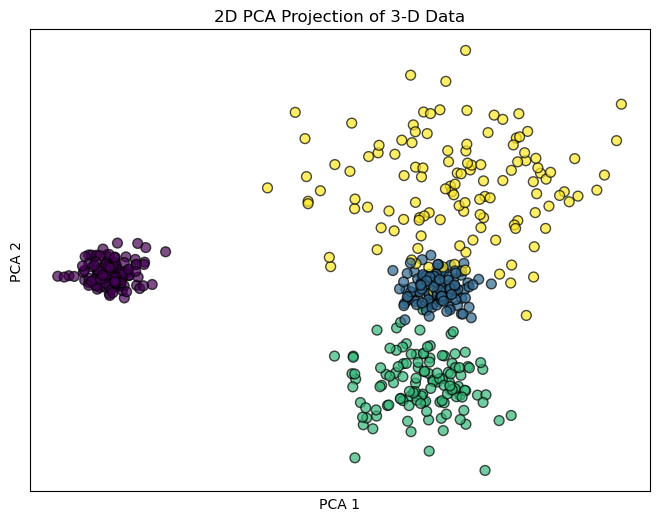

In [15]:
# Apply PCA to reduce the dimensionality to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure(figsize=(8, 6))

# Plot the 2D PCA result (right)
ax2 = fig.add_subplot(111)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_, cmap='viridis', s=50, alpha=0.7, edgecolor='k')
ax2.set_title("2D PCA Projection of 3-D Data")
ax2.set_xlabel("PCA 1")
ax2.set_ylabel("PCA 2")
ax2.set_xticks([])
ax2.set_yticks([])
plt.show()

### Exercise 5. What can you say about this PCA result?


The PCA result looks almost exactly like the original plot. It maintains the densities from the original plot. It also maintained the original separation between the blobs. PCA and t-SNE were faster than UMAP. PCA out performed both the other algorithms

### Congratulations! You're ready to move on to your next lesson!


## Author

<a href="https://www.linkedin.com/in/jpgrossman/" target="_blank">Jeff Grossman</a>

### Other Contributors
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>



<!-- ## Changelog

| Date | Version | Changed by | Change Description |
|:------------|:------|:------------------|:---------------------------------------|
| 2024-11-05 | 1.0  | Jeff Grossman    | Create content | -->



## <h3 align="center"> © IBM Corporation. All rights reserved. <h3/>
